<a href="https://colab.research.google.com/github/Divya6859/real-estate-price-prediction/blob/main/RealEstate_Price_Prediction_using_ML_with_Web_Scraping_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
from bs4 import BeautifulSoup
import csv
import time

base_url = "https://www.magicbricks.com/1-bhk-flats-for-rent-in-bangalore-pppfr/page-{}"

headers = {
    "User-Agent": "Mozilla/5.0"
}

all_data = []

# Loop through multiple pages
for page in range(1, 21):  # scrape 10 pages (can increase)

    url = base_url.format(page)
    print(f"Scraping Page {page}...")

    response = requests.get(url, headers=headers)

    if response.status_code != 200:
        print("Failed to fetch page", page)
        continue

    soup = BeautifulSoup(response.content, 'html.parser')
    listings = soup.find_all('div', class_='mb-srp__list')

    for listing in listings:
        title = listing.find('h2', class_='mb-srp__card--title')
        title = title.text.strip() if title else "NA"

        price = listing.find('div', class_='mb-srp__card__price--amount')
        price = price.text.strip() if price else "NA"

        summary = listing.find_all('div', class_='mb-srp__card__summary--value')

        furnished = summary[0].text.strip() if len(summary) > 0 else "NA"
        bathroom = summary[1].text.strip() if len(summary) > 1 else "NA"
        tenant = summary[2].text.strip() if len(summary) > 2 else "NA"
        status = summary[3].text.strip() if len(summary) > 3 else "NA"
        carpet_area = summary[4].text.strip() if len(summary) > 4 else "NA"

        all_data.append([title, price, furnished, bathroom, carpet_area, tenant, status])

    time.sleep(2)  # avoid blocking

# Save to CSV
with open('magicbricks_listings_full.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['Title', 'Price', 'Furnished', 'Bathroom', 'Carpet Area', 'Tenant', 'Status'])
    writer.writerows(all_data)

print("Scraping completed. Total rows:", len(all_data))

Scraping Page 1...
Scraping Page 2...
Scraping Page 3...
Scraping Page 4...
Scraping Page 5...
Scraping Page 6...
Scraping Page 7...
Scraping Page 8...
Scraping Page 9...
Scraping Page 10...
Scraping Page 11...
Scraping Page 12...
Scraping Page 13...
Scraping Page 14...
Scraping Page 15...
Scraping Page 16...
Scraping Page 17...
Scraping Page 18...
Scraping Page 19...
Scraping Page 20...
Scraping completed. Total rows: 600


REAL ESTATE ML PIPELINE

LOAD DATA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("magicbricks_listings_full.csv")
df.head()

,Title,Price,Furnished,Bathroom,Carpet Area,Tenant,Status
0,"1 BHK Flat for Rent in Sarjapura, Bangalore","₹32,000",Semi-Furnished,1,643 sqft,Bachelors/Family,Immediately
1,"1 BHK Flat for Rent in Mysore Road, Bangalore","₹15,000",Semi-Furnished,1,540 sqft,Bachelors,From May '26
2,"1 BHK Flat for Rent in Electronic City, Banga...","₹10,000",Semi-Furnished,1,345 sqft,Bachelors/Family,Immediately
3,"1 BHK Flat for Rent in Sarjapura, Bangalore","₹30,000",Semi-Furnished,1,448 sqft,Bachelors,From Apr '26
4,"1 BHK Flat for Rent in Sarjapur Road, Bangalore","₹35,000",Furnished,1,3000 sqft,Bachelors/Family,Immediately


In [3]:
df.isnull().sum()

,0
Title,0
Price,0
Furnished,0
Bathroom,0
Carpet Area,3
Tenant,1
Status,3


CLEANING

In [4]:
# Price
df['Price'] = df['Price'].astype(str).str.replace('[^0-9]', '', regex=True)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Carpet Area
df['Carpet Area'] = df['Carpet Area'].astype(str)
df['Carpet Area'] = df['Carpet Area'].str.replace('[^0-9.]', '', regex=True)
df['Carpet Area'] = pd.to_numeric(df['Carpet Area'], errors='coerce')

# Bathroom
df['Bathroom'] = pd.to_numeric(df['Bathroom'], errors='coerce')

FEATURE ENGINEERING

Extract Location

In [5]:
df['Location'] = df['Title'].str.extract(r'in (.*)')
df['Location'] = df['Location'].fillna("Unknown")

Extract BHK

In [6]:
df['BHK'] = df['Title'].str.extract(r'(\d+)').astype(float)
df['BHK'] = df['BHK'].fillna(df['BHK'].median())

In [7]:
# Interaction feature
df['Area_per_BHK'] = df['Carpet Area'] / df['BHK']
df['Area_per_BHK'] = df['Area_per_BHK'].fillna(df['Area_per_BHK'].median())

HANDLE NULL VALUES

In [8]:
# Categorical
df['Furnished'] = df['Furnished'].fillna(df['Furnished'].mode()[0])
df['Tenant'] = df['Tenant'].fillna(df['Tenant'].mode()[0])
df['Status'] = df['Status'].fillna(df['Status'].mode()[0])

# Numeric
df['Carpet Area'] = df['Carpet Area'].fillna(df['Carpet Area'].median())
df['Bathroom'] = df['Bathroom'].fillna(df['Bathroom'].median())

# Drop missing price
df = df.dropna(subset=['Price'])

REMOVE OUTLIERS

In [9]:
df = df[df['Price'] < df['Price'].quantile(0.95)]

In [10]:
print("Shape:", df.shape)
print(df.head())
print(df.isnull().sum())

Shape: (546, 10)
                                               Title    Price       Furnished  \
0       1 BHK Flat  for Rent in Sarjapura, Bangalore  32000.0  Semi-Furnished   
1     1 BHK Flat  for Rent in Mysore Road, Bangalore  15000.0  Semi-Furnished   
2  1 BHK Flat  for Rent in Electronic City, Banga...  10000.0  Semi-Furnished   
3       1 BHK Flat  for Rent in Sarjapura, Bangalore  30000.0  Semi-Furnished   
4   1 BHK Flat  for Rent in Sarjapur Road, Bangalore  35000.0       Furnished   

   Bathroom  Carpet Area            Tenant        Status  \
0       1.0        643.0  Bachelors/Family   Immediately   
1       1.0        540.0         Bachelors  From May '26   
2       1.0        345.0  Bachelors/Family   Immediately   
3       1.0        448.0         Bachelors  From Apr '26   
4       1.0       3000.0  Bachelors/Family   Immediately   

                     Location  BHK  Area_per_BHK  
0        Sarjapura, Bangalore  1.0         643.0  
1      Mysore Road, Bangalore  1.

In [11]:
top_locations = df['Location'].value_counts().nlargest(5).index
df['Location'] = df['Location'].apply(lambda x: x if x in top_locations else 'Other')

EDA

Price Distribution

In [12]:
sns.set(style="whitegrid")

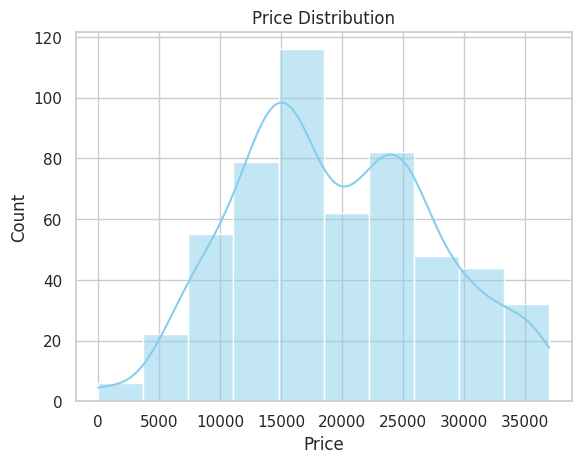

In [13]:
sns.histplot(df['Price'], bins=10, kde=True, color='skyblue')
plt.title("Price Distribution")
plt.show()

Area vs Price

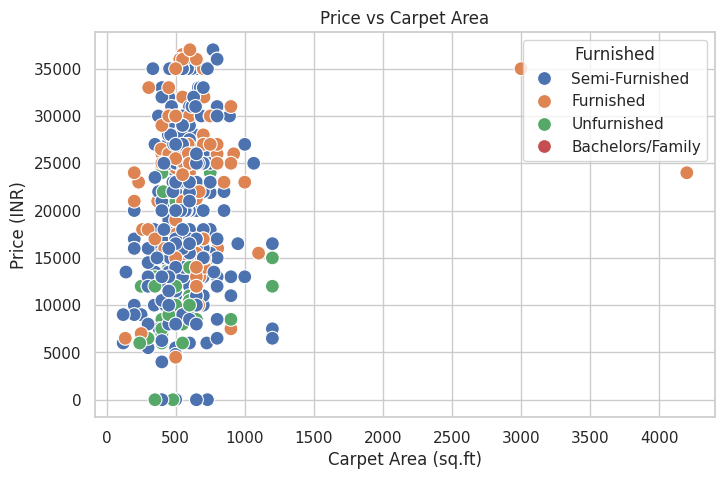

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Carpet Area', y='Price', hue='Furnished', s=100)
plt.title("Price vs Carpet Area")
plt.xlabel("Carpet Area (sq.ft)")
plt.ylabel("Price (INR)")
plt.show()

Location vs Price

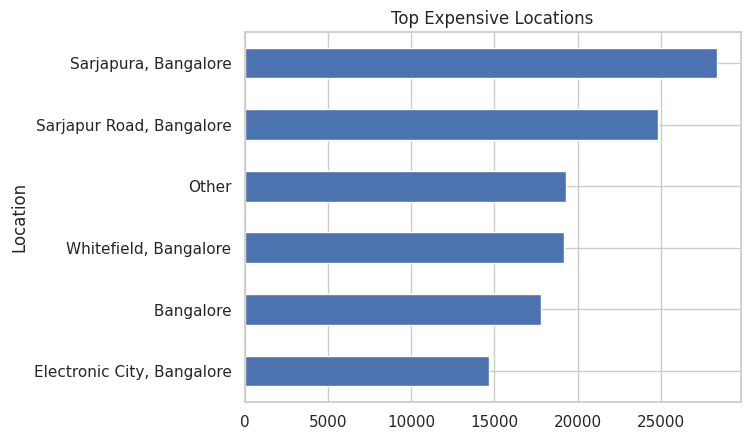

In [15]:
df.groupby('Location')['Price'].mean().sort_values().tail(10).plot(kind='barh')
plt.title("Top Expensive Locations")
plt.show()

Furnished vs Price

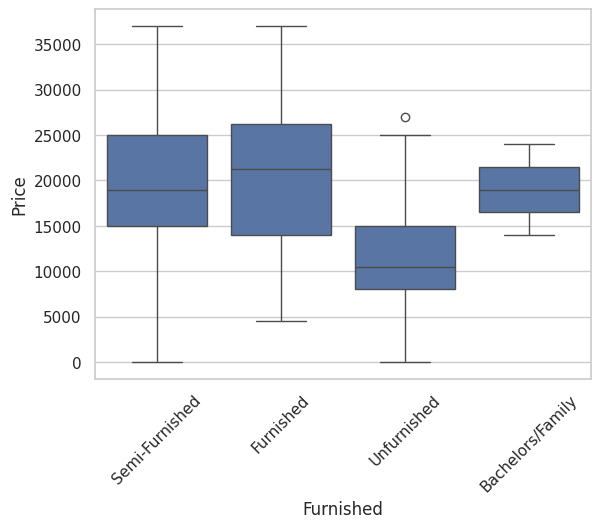

In [16]:
sns.boxplot(x='Furnished', y='Price', data=df)
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_24810/4226760515.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Furnished', palette='Set2')


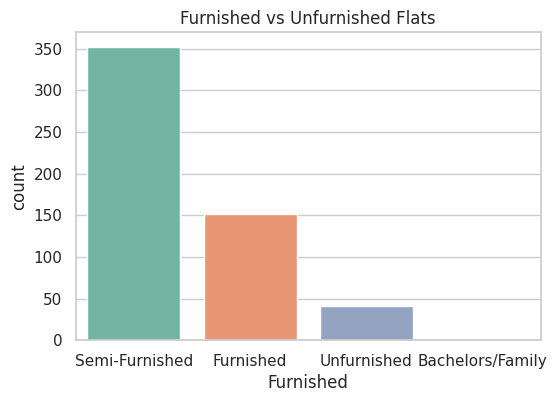

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Furnished', palette='Set2')
plt.title("Furnished vs Unfurnished Flats")
plt.show()

Tenant Type

/tmp/ipykernel_24810/270702563.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Tenant', palette='Set2')


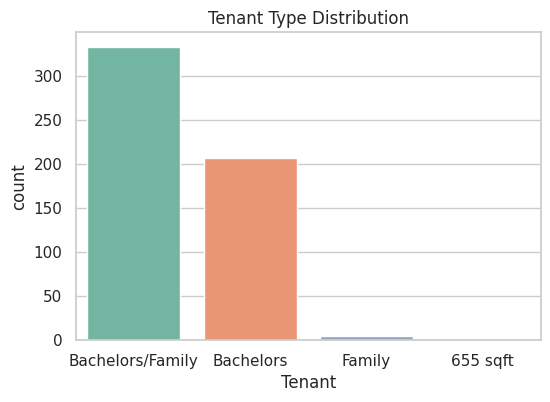

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Tenant', palette='Set2')
plt.title("Tenant Type Distribution")
plt.show()

/tmp/ipykernel_24810/2661754981.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', palette='Set1')


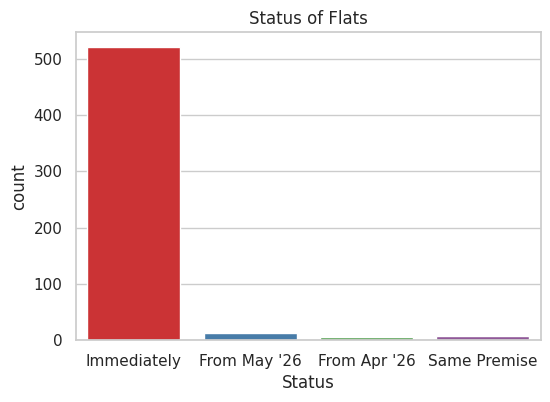

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Status', palette='Set1')
plt.title("Status of Flats")
plt.show()

ENCODING

In [20]:
df_encoded = pd.get_dummies(df, columns=['Furnished','Tenant','Status','Location'], drop_first=True)

DEFINE X & y

In [21]:
X = df_encoded.drop(['Price', 'Title'], axis=1)
y = df_encoded['Price']

TRAIN TEST SPLIT

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

MODEL BUILDING

In [23]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [25]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

EVALUATION

In [26]:
from sklearn.metrics import mean_absolute_error, r2_score

def evaluate(name, y_test, y_pred):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest", y_test, rf_pred)
evaluate("XGBoost", y_test, xgb_pred)


Linear Regression
MAE: 6715.111043212566
R2: 0.09063877571863632

Random Forest
MAE: 6560.676871061699
R2: 0.12243938116309472

XGBoost
MAE: 6092.480679043857
R2: 0.17881428010557854


PREDICTION

In [27]:
sample = X_test.iloc[0:1]
actual = y_test.iloc[0]

predicted = xgb.predict(sample)[0]

print("Actual Price:", actual)
print("Predicted Price:", predicted)

Actual Price: 16000.0
Predicted Price: 15917.159


In [28]:
def predict_price(area, bath, bhk):

    sample = X.iloc[0:1].copy()

    sample['Carpet Area'] = area
    sample['Bathroom'] = bath
    sample['BHK'] = bhk

    # reset categorical
    for col in sample.columns:
        if 'Location_' in col or 'Furnished_' in col or 'Tenant_' in col or 'Status_' in col:
            sample[col] = 0

    # Example settings
    if 'Location_Whitefield' in sample.columns:
        sample['Location_Whitefield'] = 1

    if 'Furnished_Semi-Furnished' in sample.columns:
        sample['Furnished_Semi-Furnished'] = 1

    if 'Tenant_Family' in sample.columns:
        sample['Tenant_Family'] = 1

    if 'Status_Immediately' in sample.columns:
        sample['Status_Immediately'] = 1

    pred = xgb.predict(sample)[0]

    print("Predicted Price:", pred)
predict_price(1200, 2, 2)

Predicted Price: 15475.735


FEATURE IMPORTANCE

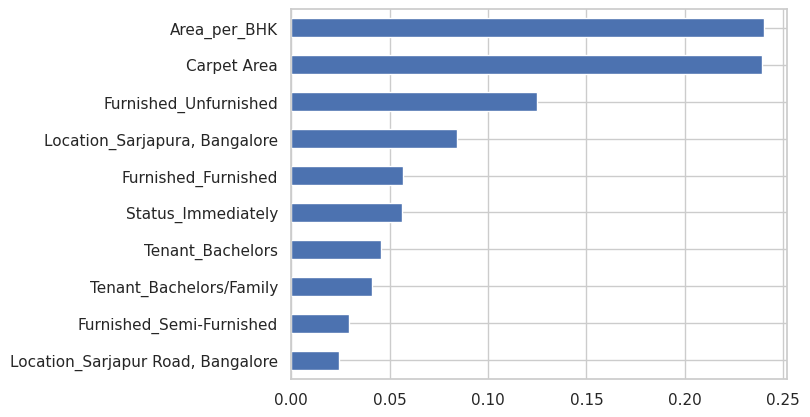

In [29]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().tail(10).plot(kind='barh')
plt.show()